# Advanced Data Science Lab

## Assignment 02

### Retail Sales Dashboard using Streamlit

**Name :** Manthan Sankpal

**PRN :** 125M1H064

**Class :** SY MCA

**Course :** Advanced Data Science Lab

---

## Objective

To develop an interactive Streamlit web application that analyzes retail sales data and visualizes product performance using summary statistics and charts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("sales.csv")

In [3]:
df.head()

,Date,StoreID,ProductCategory,UnitsSold,Revenue,Cost
0,2023-01-01,S2,Clothing,19,879.70,130.31
1,2023-01-02,S2,Clothing,3,408.06,198.29
2,2023-01-03,S2,Electronics,11,760.66,439.35
3,2023-01-04,S2,Clothing,9,654.45,340.31
4,2023-01-05,S2,Clothing,1,249.59,214.99


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 100
Columns : 6


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             100 non-null    str    
 1   StoreID          100 non-null    str    
 2   ProductCategory  100 non-null    str    
 3   UnitsSold        100 non-null    int64  
 4   Revenue          100 non-null    float64
 5   Cost             100 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 6.9 KB


In [7]:
df.isnull().sum()

Date               0
StoreID            0
ProductCategory    0
UnitsSold          0
Revenue            0
Cost               0
dtype: int64

In [11]:
# Convert Date column into datetime format

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,StoreID,ProductCategory,UnitsSold,Revenue,Cost
0,2023-01-01,S2,Clothing,19,879.70,130.31
1,2023-01-02,S2,Clothing,3,408.06,198.29
2,2023-01-03,S2,Electronics,11,760.66,439.35
3,2023-01-04,S2,Clothing,9,654.45,340.31
4,2023-01-05,S2,Clothing,1,249.59,214.99


In [12]:
mean_revenue = df["Revenue"].mean()
median_revenue = df["Revenue"].median()

print("Mean Revenue :", round(mean_revenue, 2))
print("Median Revenue :", round(median_revenue, 2))

Mean Revenue : 559.84
Median Revenue : 550.98


In [13]:
category_summary = (
    df.groupby("ProductCategory")[["UnitsSold", "Revenue"]].sum().reset_index()
)
category_summary

,ProductCategory,UnitsSold,Revenue
0,Clothing,295,16681.11
1,Electronics,425,24165.45
2,Groceries,256,15137.83


In [14]:
daily_revenue = (
    df.groupby("Date")["Revenue"].sum().reset_index()
)
daily_revenue.head()

,Date,Revenue
0,2023-01-01,879.70
1,2023-01-02,408.06
2,2023-01-03,760.66
3,2023-01-04,654.45
4,2023-01-05,249.59


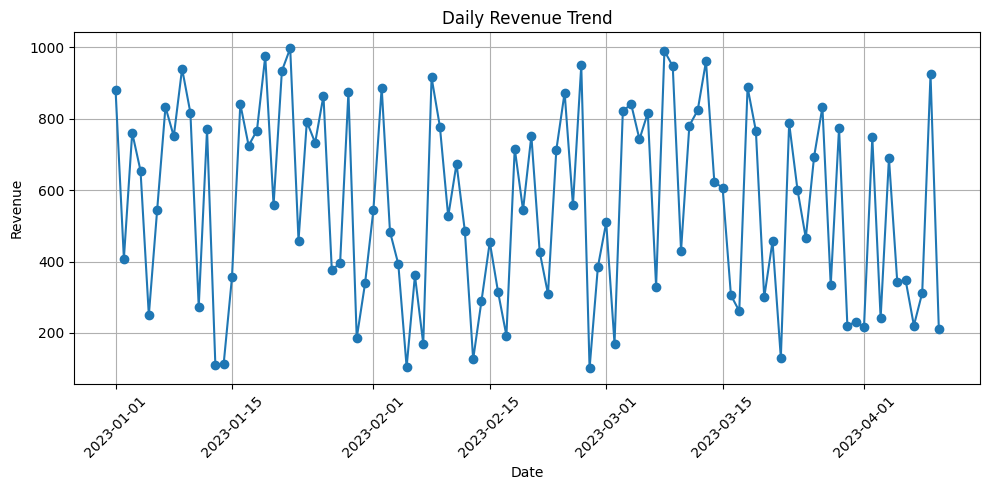

In [15]:
plt.figure(figsize=(10,5))

plt.plot(
    daily_revenue["Date"],
    daily_revenue["Revenue"],
    marker="o"
)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

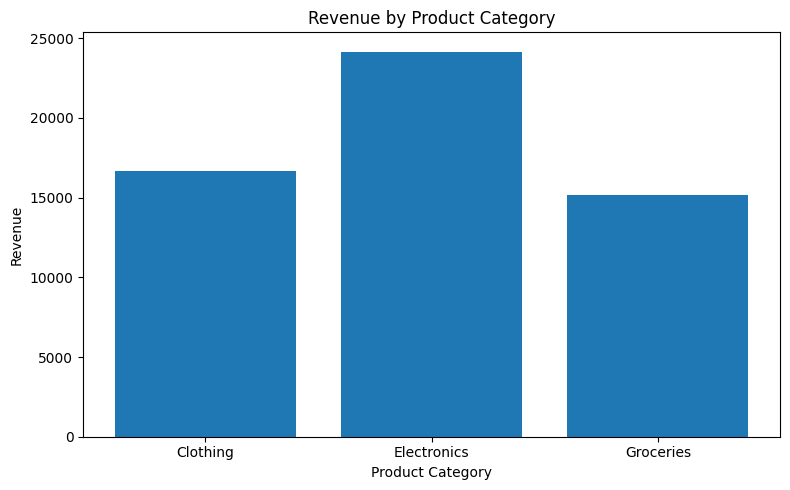

In [16]:
plt.figure(figsize=(8,5))

plt.bar(
    category_summary["ProductCategory"],
    category_summary["Revenue"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()